In [4]:
import optuna
from optuna.samplers import TPESampler
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [5]:
x_train = pd.read_csv("data_train_x.csv")
y_train = pd.read_csv("data_train_y.csv")
x_test = pd.read_csv("data_test_x.csv")
y_test = pd.read_csv("data_test_y.csv")

print("训练集大小:", len(x_train))
print("外部验证集大小:", len(x_test))

训练集大小: 918
外部验证集大小: 234


In [6]:
import joblib
best_model = joblib.load('XGB_regression_model.pkl')
y_pred_train = best_model.predict(x_train)
y_pred_test = best_model.predict(x_test)

y_pred_test = best_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\n测试集性能:")
print(f"均方误差 (MSE): {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"决定系数 (R²): {r2:.4f}")



测试集性能:
均方误差 (MSE): 42.6800
均方根误差 (RMSE): 6.5330
平均绝对误差 (MAE): 4.3670
决定系数 (R²): 0.5835


In [7]:
y_pred_train = best_model.predict(x_train)

mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print("\ntrain性能:")
print(f"均方误差 (MSE): {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"决定系数 (R²): {r2:.4f}")



train性能:
均方误差 (MSE): 4.1363
均方根误差 (RMSE): 2.0338
平均绝对误差 (MAE): 1.3066
决定系数 (R²): 0.9444


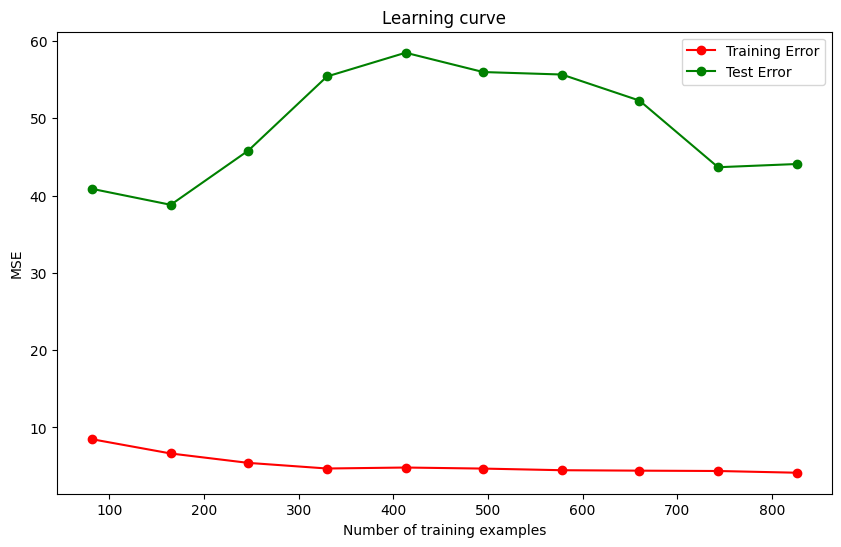

In [8]:
def plot_learning_curve(model, X, y):
    
    from sklearn.model_selection import learning_curve
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=10, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Error')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Test Error')
    plt.xlabel('Number of training examples')
    plt.ylabel('MSE')
    plt.title('Learning curve')
    plt.legend(loc='best')
    plt.show()

plot_learning_curve(best_model, x_train, y_train)

 98%|===================| 899/918 [00:35<00:00]        

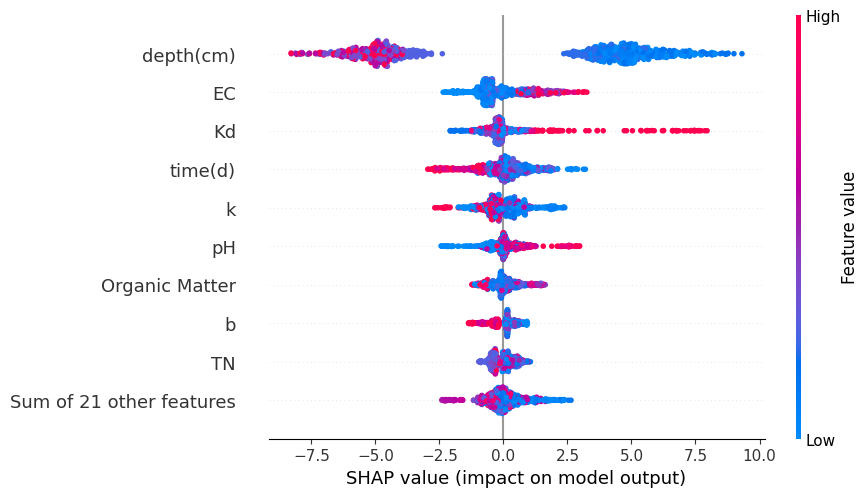

In [10]:
import shap
explainer = shap.Explainer(best_model, x_train)
shap_values = explainer(x_train)
shap.plots.beeswarm(shap_values)

In [11]:
y_pred_train_pd = pd.DataFrame()
y_pred_train_pd['S(mg/g)_pred'] = y_pred_train
y_pred_train_pd

,S(mg/g)_pred
0,12.251593
1,13.294342
2,12.813681
3,13.703958
4,12.463528
...,...
913,7.004226
914,2.714010
915,1.997465
916,1.808231


In [12]:
y_pred_test_pd = pd.DataFrame()
y_pred_test_pd['S(mg/g)_pred'] = y_pred_test
y_pred_test_pd

,S(mg/g)_pred
0,17.059633
1,15.950417
2,16.326586
3,17.580317
4,16.331476
...,...
229,8.137180
230,3.740300
231,2.940882
232,2.773767


In [13]:
XGB_train_result = x_train.join(y_train).join(y_pred_train_pd)
XGB_train_result.to_csv('XGB_train_result.csv')
XGB_test_result = x_test.join(y_test).join(y_pred_test_pd)
XGB_test_result.to_csv('XGB_test_result.csv')